In [2]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from scipy import stats

Dataset is found at: https://data.ny.gov/Transportation/MTA-Subway-Hourly-Ridership-2020-2024/wujg-7c2s/about_data

I am performing data analysis to answer a question:
- What factors influence hourly subway ridership
- Predict when a station will experience high ridership (>90th percentile per station)

I intend to visualize the routes that passengers take. I also intend to add weather dataset to enhance predictability.

In [3]:
url = "https://data.ny.gov/resource/wujg-7c2s.json"

params = {"$limit": 1000000}

print("Requesting data...")
response = requests.get(url, params=params)

if response.status_code == 200:
    data = response.json()
    df = pd.DataFrame(data)
    print(f"Loaded {len(df)} rows.")
else:
    print("Error fetching data:", response.status_code)

Requesting data...
Loaded 1000000 rows.


In [4]:
df_head = df.head()
df_head

,transit_timestamp,transit_mode,station_complex_id,station_complex,borough,payment_method,fare_class_category,ridership,transfers,latitude,longitude,georeference,:@computed_region_kjdx_g34t,:@computed_region_yamh_8v7k,:@computed_region_wbg7_3whc
0,2022-09-20T05:00:00.000,subway,58,"Coney Island-Stillwell Av (D,F,N,Q)",Brooklyn,metrocard,Metrocard - Fair Fare,32.0,5.0,40.577423,-73.98123,"{'type': 'Point', 'coordinates': [-73.98123, 4...",2090,894,903
1,2022-09-20T19:00:00.000,subway,138,Canarsie-Rockaway Pkwy (L),Brooklyn,metrocard,Metrocard - Unlimited 30-Day,12.0,0.0,40.646652,-73.90185,"{'type': 'Point', 'coordinates': [-73.90185, 4...",2090,894,819
2,2022-09-20T15:00:00.000,subway,635,"South Ferry (1)/Whitehall St (R,W)",Manhattan,metrocard,Metrocard - Seniors & Disability,60.0,18.0,40.703087,-74.01299,"{'type': 'Point', 'coordinates': [-74.01299, 4...",2095,749,720
3,2022-09-20T11:00:00.000,subway,358,"Newkirk Av-Little Haiti (2,5)",Brooklyn,metrocard,Metrocard - Seniors & Disability,16.0,5.0,40.63997,-73.94841,"{'type': 'Point', 'coordinates': [-73.94841, 4...",2090,894,888
4,2022-09-20T15:00:00.000,subway,611,"Times Sq-42 St (N,Q,R,W,S,1,2,3,7)/42 St (A,C,E)",Manhattan,omny,OMNY - Full Fare,2116.0,12.0,40.75731,-73.986755,"{'type': 'Point', 'coordinates': [-73.986755, ...",2095,749,795


In [5]:
print(df.columns)
print(df.dtypes)

Index(['transit_timestamp', 'transit_mode', 'station_complex_id',
       'station_complex', 'borough', 'payment_method', 'fare_class_category',
       'ridership', 'transfers', 'latitude', 'longitude', 'georeference',
       ':@computed_region_kjdx_g34t', ':@computed_region_yamh_8v7k',
       ':@computed_region_wbg7_3whc'],
      dtype='object')
transit_timestamp              object
transit_mode                   object
station_complex_id             object
station_complex                object
borough                        object
payment_method                 object
fare_class_category            object
ridership                      object
transfers                      object
latitude                       object
longitude                      object
georeference                   object
:@computed_region_kjdx_g34t    object
:@computed_region_yamh_8v7k    object
:@computed_region_wbg7_3whc    object
dtype: object


In [6]:
df.drop(columns=['georeference', ':@computed_region_kjdx_g34t', ':@computed_region_yamh_8v7k', ':@computed_region_wbg7_3whc'], inplace=True)
print("Dropped unnecessary columns.")
print(df.columns)

Dropped unnecessary columns.
Index(['transit_timestamp', 'transit_mode', 'station_complex_id',
       'station_complex', 'borough', 'payment_method', 'fare_class_category',
       'ridership', 'transfers', 'latitude', 'longitude'],
      dtype='object')


In [7]:
# basic dataset cleaning
df['transit_timestamp'] = pd.to_datetime(df['transit_timestamp'])
df['transit_mode'] = df['transit_mode'].astype('str')
df['station_complex_id'] = df['station_complex_id'].astype('str')
df['station_complex'] = df['station_complex'].astype('str')
df['borough'] = df['borough'].astype('str')
df['payment_method'] = df['payment_method'].astype('str')
df['fare_class_category'] = df['fare_class_category'].astype('str')
df['ridership'] = pd.to_numeric(df['ridership'], errors='coerce')
df['transfers'] = pd.to_numeric(df['transfers'], errors='coerce')
df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')

In [8]:
print(df.dtypes)

transit_timestamp      datetime64[ns]
transit_mode                   object
station_complex_id             object
station_complex                object
borough                        object
payment_method                 object
fare_class_category            object
ridership                     float64
transfers                     float64
latitude                      float64
longitude                     float64
dtype: object


In [9]:
df['ridership'].describe()
# obvious outliers here, remove them

count    1000000.000000
mean          47.203284
std          136.668137
min            1.000000
25%            4.000000
50%           14.000000
75%           41.000000
max         7999.000000
Name: ridership, dtype: float64

In [10]:
df = df[df['ridership'] < 50]

In [11]:
df['ridership'].describe()

count    787639.000000
mean         13.237892
std          12.415382
min           1.000000
25%           3.000000
50%           9.000000
75%          20.000000
max          49.000000
Name: ridership, dtype: float64

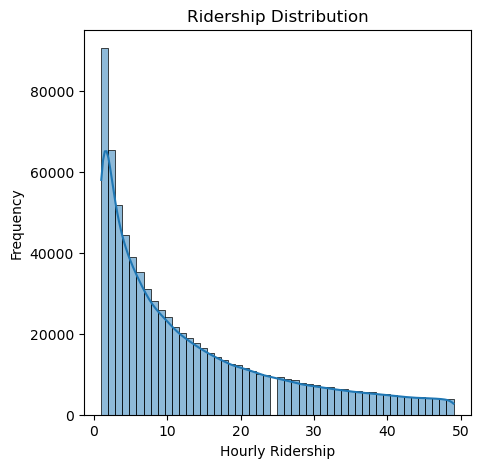

In [12]:
# data exploring
plt.figure(figsize=(5,5))
sns.histplot(df['ridership'], bins=50, kde=True)
plt.title("Ridership Distribution")
plt.xlabel("Hourly Ridership")
plt.ylabel("Frequency")
plt.show()

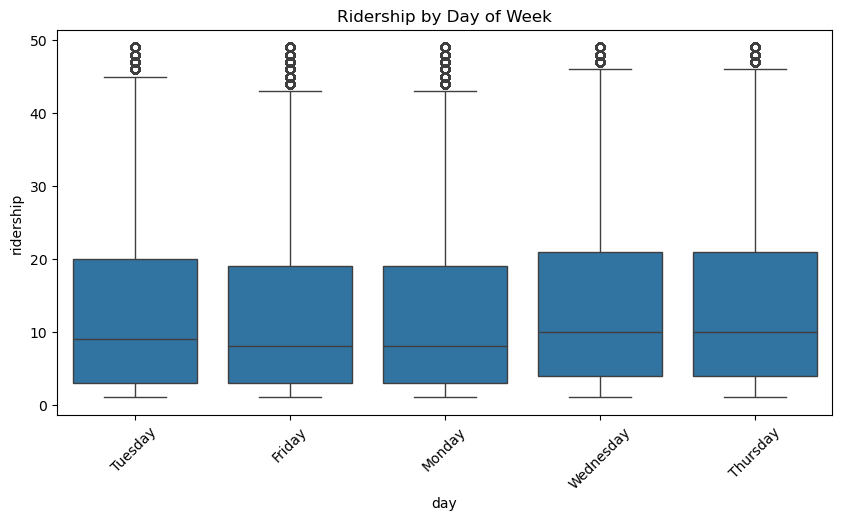

In [13]:
df['day'] = df['transit_timestamp'].dt.day_name()
plt.figure(figsize=(10,5))
sns.boxplot(x="day", y="ridership", data=df)
plt.title("Ridership by Day of Week")
plt.xticks(rotation=45)
plt.show()
# outliers are weird here. should I be cutting out >50 or no. maybe filter by just metro

In [15]:
print(df.columns)

Index(['transit_timestamp', 'transit_mode', 'station_complex_id',
       'station_complex', 'borough', 'payment_method', 'fare_class_category',
       'ridership', 'transfers', 'latitude', 'longitude', 'day'],
      dtype='object')


In [27]:
# plot feature importance using built-in function
%pip install xgboost
from numpy import loadtxt
from xgboost import XGBRegressor
from xgboost import plot_importance
from matplotlib import pyplot


Note: you may need to restart the kernel to use updated packages.


/opt/homebrew/anaconda3/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [17:12:57] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.11698237773602153
              precision    recall  f1-score   support

           0      0.162     0.192     0.176      1379
           1      0.181     0.164     0.172      1086
           2      0.206     0.251     0.227      1014
           3      0.169     0.250     0.202      1225
           4      0.128     0.180     0.149      1648
           5      0.141     0.144     0.143      1980
           6      0.138     0.112     0.124      1778
           7      0.120     0.168     0.140      1408
           8      0.129     0.204     0.158      1368
           9      0.102     0.133     0.115      1753
          10      0.077     0.069     0.073      1886
          11      0.072     0.060     0.065      1954
          12      0.075     0.048     0.058      1905
          13      0.079     0.084     0.081      1871
          14      0.080     0.087     0.084      1749
          15      0.098     0.072     0.083      1627
          16      0.096     0.073     0.083      15

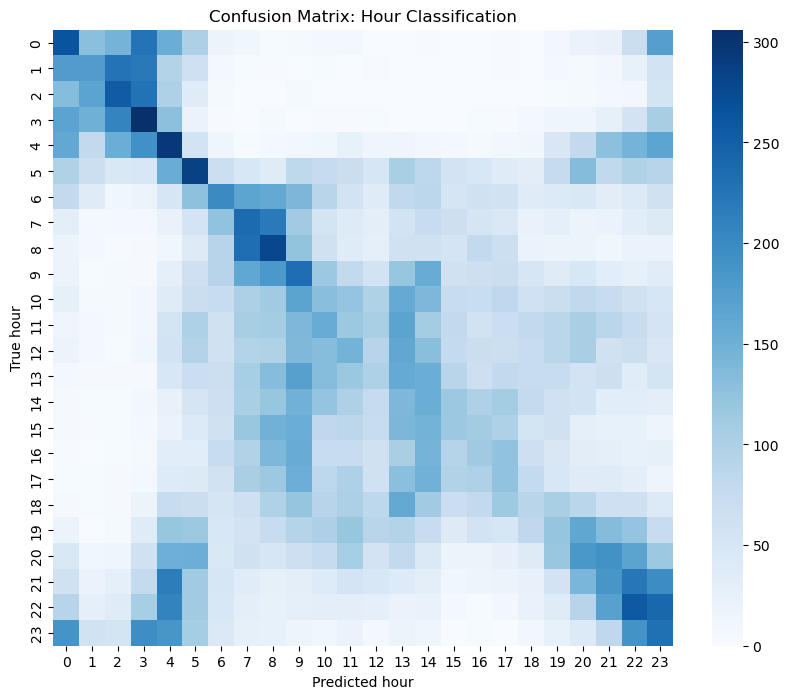

<Figure size 800x1000 with 0 Axes>

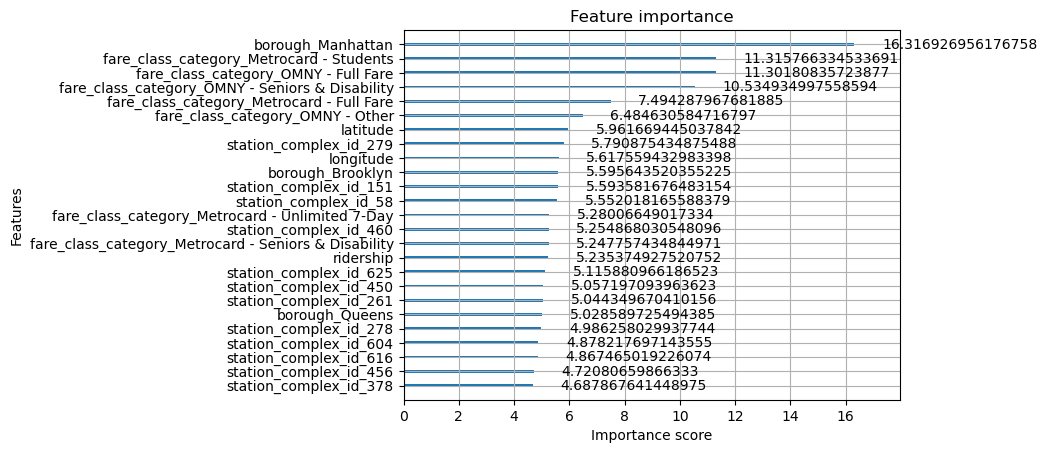

In [30]:
# classify hour of day (0-23) as target buckets
# prepare X and y
X = df.drop(columns=["transit_timestamp"])
y = df['transit_timestamp'].dt.hour  # labels 0..23

# one-hot encode categorical columns (keep numeric cols)
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
if cat_cols:
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# optional: subsample to speed up training (remove or reduce if you want full data)
sample_frac = 0.25
X_samp = X.sample(frac=sample_frac, random_state=42)
y_samp = y.loc[X_samp.index]

# train / test split (stratify to keep hour distribution)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_samp, y_samp, test_size=0.2, stratify=y_samp, random_state=42
)

# classifier
from xgboost import XGBClassifier, plot_importance
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

model = XGBClassifier(n_jobs=-1, random_state=42, use_label_encoder=False, eval_metric="mlogloss")
model.fit(X_train, y_train)

# evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))

# confusion matrix (visual)
cm = confusion_matrix(y_test, y_pred, labels=sorted(y.unique()))
plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap="Blues", xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()), fmt="d")
plt.xlabel("Predicted hour")
plt.ylabel("True hour")
plt.title("Confusion Matrix: Hour Classification")
plt.show()

# feature importance (top 25)
plt.figure(figsize=(8,10))
plot_importance(model, max_num_features=25, importance_type="gain")
pyplot.show()
# ...existing code...